# SVM Spam Detection

This notebook uses Support Vector Machine to classify emails as **spam** or **not spam**. The implementation uses a small text dataset, TF-IDF vectorization, and a linear SVM classifier.

The notebook includes the required sections: Problem Statement, Understanding of Dataset, Theory, Mathematical Representation, Diagram, Pseudocode, Expected Output, and Obtained Output. It also includes simple data cleaning, EDA, feature engineering, and evaluation using accuracy and a confusion matrix.

In [15]:
# Imports and Synthetic CSV Generation
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

DATA_PATH = "spam_emails.csv"
TEXT_COL = "message"
TARGET_COL = "label"

np.random.seed(42)
spam_templates = [
    "Congratulations! You have won a free prize. Click now to claim.",
    "Urgent: Your account is blocked. Verify your details immediately.",
    "You have been selected for a cash reward. Reply to receive it.",
    "Limited time offer: buy now and get 50 percent off.",
    "Win a free phone by entering the contest today.",
    "Claim your lottery prize now by clicking this link.",
    "Special promotion just for you. Free gift inside.",
    "Act fast to get the bonus money offer."
]
ham_templates = [
    "Hi team, please review the meeting notes from yesterday.",
    "Can we reschedule our call to tomorrow afternoon?",
    "The report is attached. Let me know if you need changes.",
    "Lunch at 1 pm works for me. See you then.",
    "Please find the project update in the shared folder.",
    "Thanks for your help with the assignment.",
    "I will send the invoice later today.",
    "Don't forget the team stand-up at 10 am."
]
messages = []
labels = []
for idx in range(12):
    for template in spam_templates:
        messages.append(f"{template} Offer code {idx} spam")
        labels.append(1)
    for template in ham_templates:
        messages.append(f"{template} Note {idx} team")
        labels.append(0)
df_sample = pd.DataFrame({TEXT_COL: messages, TARGET_COL: labels})
df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)
df_sample.to_csv(DATA_PATH, index=False)
print(f"✓ Sample CSV created: {DATA_PATH} with {len(df_sample)} samples")

print(f"\nFirst 5 rows of {DATA_PATH}:")
print(pd.read_csv(DATA_PATH).head())

✓ Sample CSV created: spam_emails.csv with 192 samples

First 5 rows of spam_emails.csv:
                                             message  label
0  Thanks for your help with the assignment. Note...      0
1  Hi team, please review the meeting notes from ...      0
2  Please find the project update in the shared f...      0
3  Don't forget the team stand-up at 10 am. Note ...      0
4  Urgent: Your account is blocked. Verify your d...      1


## 1. Problem Statement

Classify email messages as **spam** or **not spam** using SVM. Use text data and evaluate the model using accuracy and a confusion matrix.

## 2. Understanding of Dataset

Load the dataset and inspect the structure, labels, and basic statistics.

In [16]:
df = pd.read_csv(DATA_PATH)

print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print("\nFirst 10 rows:")
print(df.head(10))

print(f"\nDataset shape: {df.shape}")
print(f"Samples: {df.shape[0]}, Features: {df.shape[1]}")

print("\nColumn data types:")
print(df.dtypes)

print("\nLabel Distribution:")
print(df[TARGET_COL].value_counts())

DATASET OVERVIEW

First 10 rows:
                                             message  label
0  Thanks for your help with the assignment. Note...      0
1  Hi team, please review the meeting notes from ...      0
2  Please find the project update in the shared f...      0
3  Don't forget the team stand-up at 10 am. Note ...      0
4  Urgent: Your account is blocked. Verify your d...      1
5  Urgent: Your account is blocked. Verify your d...      1
6  Don't forget the team stand-up at 10 am. Note ...      0
7  You have been selected for a cash reward. Repl...      1
8  Congratulations! You have won a free prize. Cl...      1
9  Can we reschedule our call to tomorrow afterno...      0

Dataset shape: (192, 2)
Samples: 192, Features: 2

Column data types:
message      str
label      int64
dtype: object

Label Distribution:
label
0    96
1    96
Name: count, dtype: int64


## 3. Data Cleaning

Check for missing values, duplicates, and empty messages.

In [17]:
print("="*60)
print("DATA CLEANING")
print("="*60)

print("\n1. Missing Values Check:")
missing = df.isnull().sum()
print(f"Missing values per column:\n{missing}")
if missing.sum() == 0:
    print("✓ No missing values found")
else:
    df = df.dropna()

print("\n2. Duplicate Rows Check:")
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
if dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"× Removed {dupes} duplicate(s)")
else:
    print("✓ No duplicates found")

print("\n3. Empty Message Check:")
df[TEXT_COL] = df[TEXT_COL].astype(str)
empty_messages = (df[TEXT_COL].str.strip() == "").sum()
print(f"Empty messages: {empty_messages}")
if empty_messages > 0:
    df = df[df[TEXT_COL].str.strip() != ""].reset_index(drop=True)

print(f"\nDataset shape after cleaning: {df.shape}")

DATA CLEANING

1. Missing Values Check:
Missing values per column:
message    0
label      0
dtype: int64
✓ No missing values found

2. Duplicate Rows Check:
Duplicate rows: 0
✓ No duplicates found

3. Empty Message Check:
Empty messages: 0

Dataset shape after cleaning: (192, 2)


## 4. Exploratory Data Analysis (EDA)

Explore message lengths and class distribution.

EXPLORATORY DATA ANALYSIS


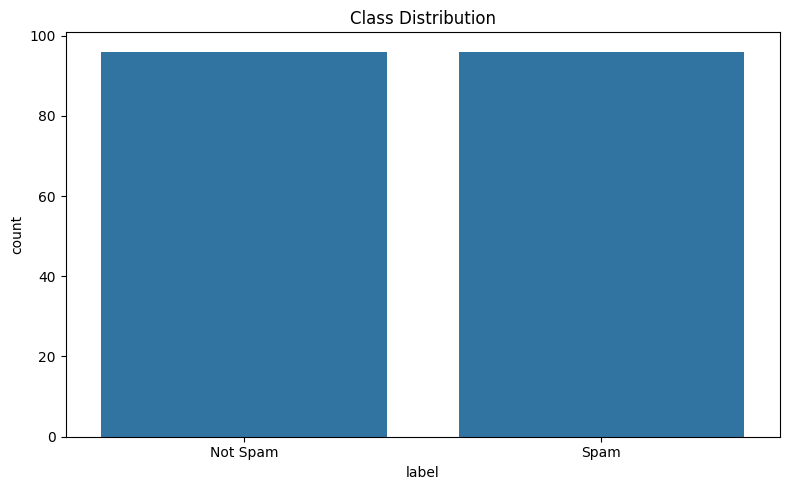

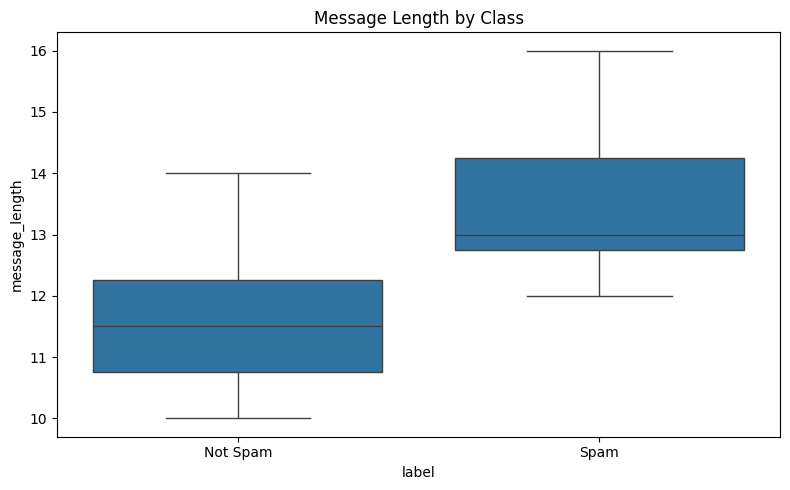


Average message length by class:
label
0    11.625
1    13.500
Name: message_length, dtype: float64


In [18]:
print("="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

df['message_length'] = df[TEXT_COL].apply(lambda text: len(text.split()))

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=TARGET_COL)
plt.xticks([0, 1], ['Not Spam', 'Spam'])
plt.title('Class Distribution')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x=TARGET_COL, y='message_length')
plt.xticks([0, 1], ['Not Spam', 'Spam'])
plt.title('Message Length by Class')
plt.tight_layout()
plt.show()

print("\nAverage message length by class:")
print(df.groupby(TARGET_COL)['message_length'].mean())

## 5. Feature Engineering & Scaling

Convert text into numeric features using TF-IDF.

In [19]:
print("="*60)
print("FEATURE ENGINEERING")
print("="*60)

X_text = df[TEXT_COL].values
y = df[TARGET_COL].values

vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(X_text)

print(f"Text samples: {len(X_text)}")
print(f"Target shape: {y.shape}")
print(f"TF-IDF matrix shape: {X.shape}")
print(f"Vocabulary size: {len(vectorizer.get_feature_names_out())}")

FEATURE ENGINEERING
Text samples: 192
Target shape: (192,)
TF-IDF matrix shape: (192, 76)
Vocabulary size: 76


## 6. Theory

Support Vector Machine is a classification algorithm that finds the best separating boundary between classes. For text classification, a linear kernel works well and keeps the implementation simple.

## 7. Mathematical Representation

- TF-IDF converts words into numerical feature values
- SVM finds the hyperplane: $f(x) = w^Tx + b$
- Predict spam if $f(x) e 0$, otherwise predict not spam

## 8. Workflow Diagram

WORKFLOW DIAGRAM


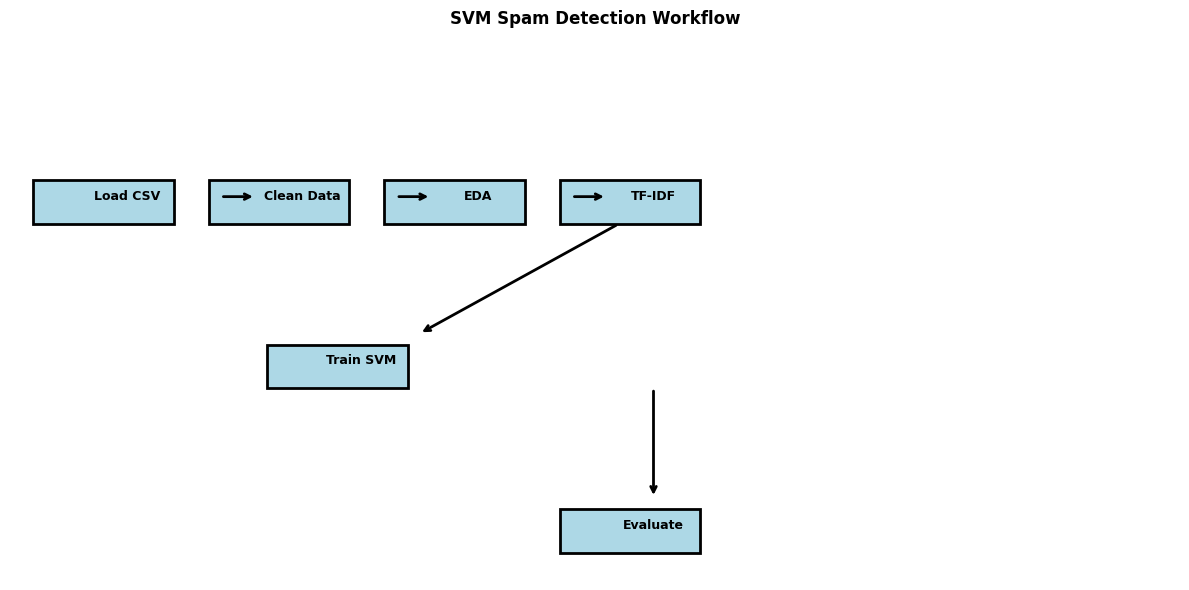

In [20]:
print("="*60)
print("WORKFLOW DIAGRAM")
print("="*60)

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

from matplotlib.patches import Rectangle
workflow_steps = [
    (0.1, 0.7, "Load CSV"),
    (0.25, 0.7, "Clean Data"),
    (0.4, 0.7, "EDA"),
    (0.55, 0.7, "TF-IDF"),
    (0.3, 0.4, "Train SVM"),
    (0.55, 0.1, "Evaluate"),
]

for step_x, step_y, label in workflow_steps:
    rect = Rectangle((step_x - 0.08, step_y - 0.05), 0.12, 0.08, facecolor='lightblue', edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(step_x, step_y, label, ha='center', va='center', fontsize=9, fontweight='bold')

arrows = [((0.18, 0.7), (0.21, 0.7)), ((0.33, 0.7), (0.36, 0.7)), ((0.48, 0.7), (0.51, 0.7)), ((0.52, 0.65), (0.35, 0.45)), ((0.55, 0.35), (0.55, 0.15))]
for start, end in arrows:
    ax.annotate('', xy=end, xytext=start, arrowprops=dict(arrowstyle='->', lw=2, color='black'))

ax.set_title('SVM Spam Detection Workflow', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Pseudocode

```
1. Load the email dataset
2. Clean the text data
3. Explore message lengths and labels
4. Convert text into TF-IDF feature vectors
5. Split into train and test sets
6. Train a linear SVM classifier
7. Predict spam or not spam on test data
8. Evaluate using accuracy and confusion matrix
9. Save the model and vectorizer
```

## 10. Train-Test Split and Model Training

In [22]:
print("="*60)
print("TRAIN-TEST SPLIT AND MODEL TRAINING")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {X_train.shape[0]} samples")
print(f"Test size: {X_test.shape[0]} samples")

model = SVC(kernel='linear')
model.fit(X_train, y_train)

print("Model trained successfully!")
sv = model.support_vectors_
n_sv = sv.shape[0] if hasattr(sv, "shape") else len(sv)
print(f"Number of support vectors: {n_sv}")

TRAIN-TEST SPLIT AND MODEL TRAINING
Train size: 153 samples
Test size: 39 samples
Model trained successfully!
Number of support vectors: 20


## 11. Evaluation: Accuracy and Confusion Matrix

In [23]:
print("="*60)
print("MODEL EVALUATION")
print("="*60)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Spam', 'Spam']))

print("Sample predictions:")
sample_indices = np.arange(min(8, len(y_test)))
for i in sample_indices:
    actual = 'Spam' if y_test[i] == 1 else 'Not Spam'
    predicted = 'Spam' if y_pred[i] == 1 else 'Not Spam'
    print(f"Actual: {actual:<8} | Predicted: {predicted:<8}")

MODEL EVALUATION
Accuracy: 1.0000

Confusion Matrix:
[[20  0]
 [ 0 19]]

Classification Report:
              precision    recall  f1-score   support

    Not Spam       1.00      1.00      1.00        20
        Spam       1.00      1.00      1.00        19

    accuracy                           1.00        39
   macro avg       1.00      1.00      1.00        39
weighted avg       1.00      1.00      1.00        39

Sample predictions:
Actual: Not Spam | Predicted: Not Spam
Actual: Spam     | Predicted: Spam    
Actual: Spam     | Predicted: Spam    
Actual: Spam     | Predicted: Spam    
Actual: Not Spam | Predicted: Not Spam
Actual: Not Spam | Predicted: Not Spam
Actual: Spam     | Predicted: Spam    
Actual: Not Spam | Predicted: Not Spam


## 12. Obtained Output

OBTAINED OUTPUT - VISUALIZATIONS


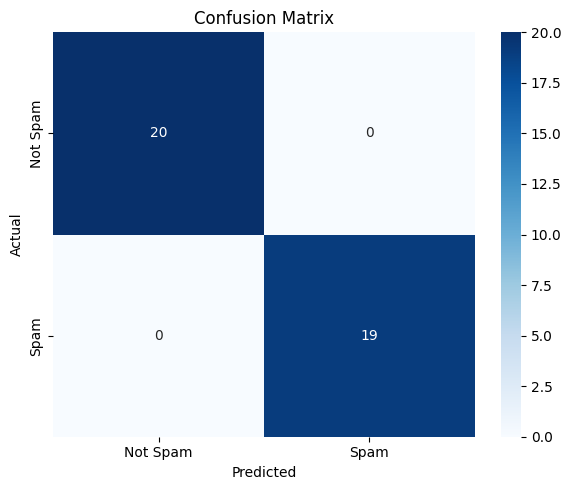

Example prediction for 'free prize click now': Spam

✓ Model and vectorizer saved successfully

Final Summary:
  Accuracy: 1.0000
  Confusion Matrix:
[[20  0]
 [ 0 19]]


In [24]:
print("="*60)
print("OBTAINED OUTPUT - VISUALIZATIONS")
print("="*60)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Spam', 'Spam'], yticklabels=['Not Spam', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Simple prediction example
new_message = ["free prize click now"]
new_vector = vectorizer.transform(new_message)
new_pred = model.predict(new_vector)[0]
print("Example prediction for 'free prize click now':", 'Spam' if new_pred == 1 else 'Not Spam')

joblib.dump(model, '9_svm_spam_model.joblib')
joblib.dump(vectorizer, '9_svm_vectorizer.joblib')

print("\n✓ Model and vectorizer saved successfully")
print("\nFinal Summary:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  Confusion Matrix:\n{cm}")